# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: FinRL
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\FinRL.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\FinRL.sqlite
Closed event type id: 110


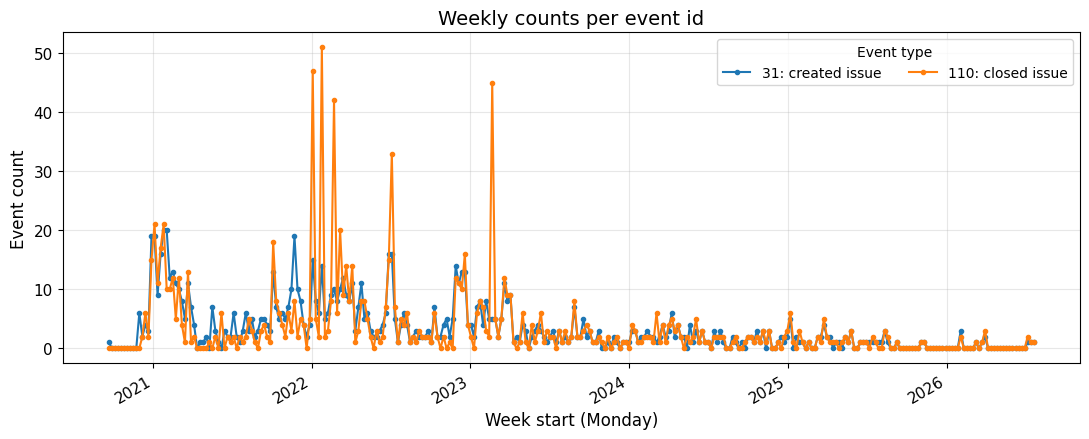

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinRL\weekly_open_closed_summary.csv


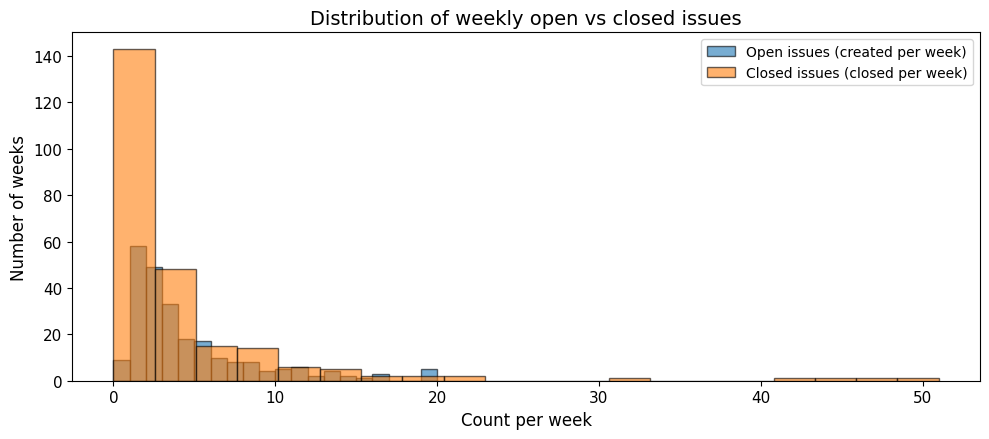

,Open issues (weekly created),Closed issues (weekly closed)
count,242.00,242.00
mean,4.17,4.28
std,4.13,7.01
min,0.00,0.00
25%,1.00,1.00
50%,3.00,2.00
75%,5.00,5.00
max,20.00,51.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("FinRL")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 14 rolling-IQR anomalies for event_type_id=110.
Joined title attribute rows: 1036 of 1036 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinRL\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2021-10-04,18,True,high,4.600000,-3.500,6.500,17,18,P1,logging & telemetry,Weekly closures show a well beyond-typical spi...,rule_based,0.7725,"[closed (#248), closed (#295), closed (#301), ...","[add 2 stock from index LQ45, Change from trad..."
1,2021-10-11,8,True,high,0.600000,-3.500,6.500,8,8,P2,runtime stability,Weekly closures show a slightly beyond-typical...,rule_based,0.9500,"[closed (#310), closed (#180), closed (#312), ...","[ModuleNotFoundError: No module named 'eRL', F..."
2,2021-11-22,8,True,high,0.045455,-3.125,7.875,7,8,P1,unknown area,Weekly closures show a near-typical spike (8 v...,rule_based,0.9500,"[closed (#361), closed (#370), closed (#358), ...","[Algos failed to extract future information., ..."
3,2022-01-03,47,True,high,9.700000,-4.375,10.625,45,47,P1,dependencies,Weekly closures show a well beyond-typical spi...,rule_based,0.6360,"[closed (#356), closed (#396), closed (#373), ...","[ccxt install problem, array size mismatch err..."
4,2022-01-24,51,True,high,13.833333,-2.500,9.500,51,51,P1,documentation,Weekly closures show a well beyond-typical spi...,rule_based,0.6225,"[closed (#334), closed (#166), closed (#347), ...",[[Suggestion] Replacement of pyfolio with quan...


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2021-10-04,43941
1,2021-10-04,44020
2,2021-10-04,44115
3,2021-10-04,44170
4,2021-10-04,44286


## 4. Anomaly plots


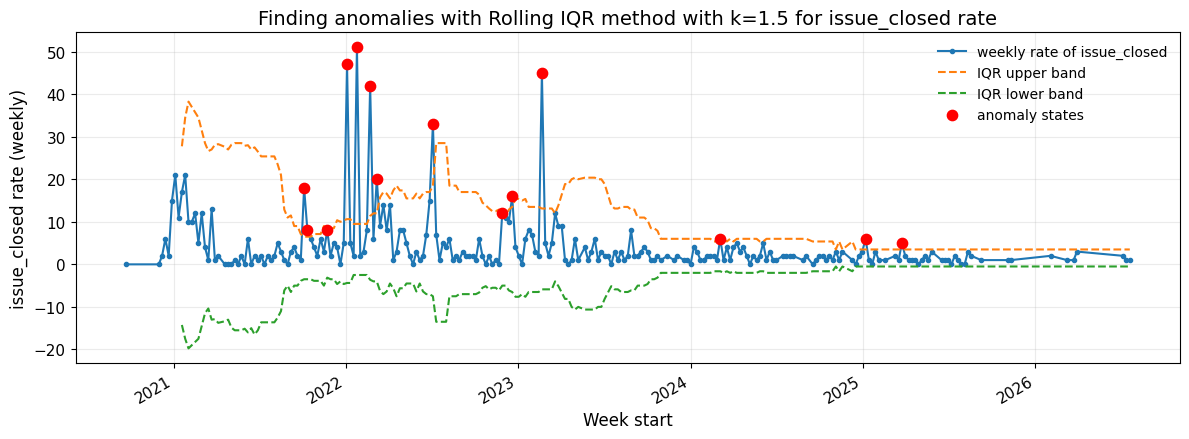

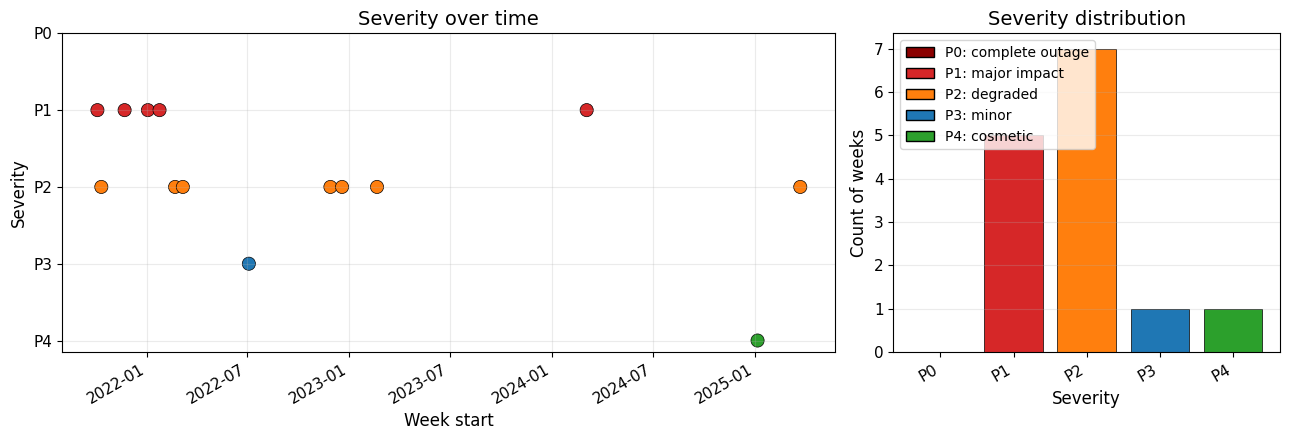

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


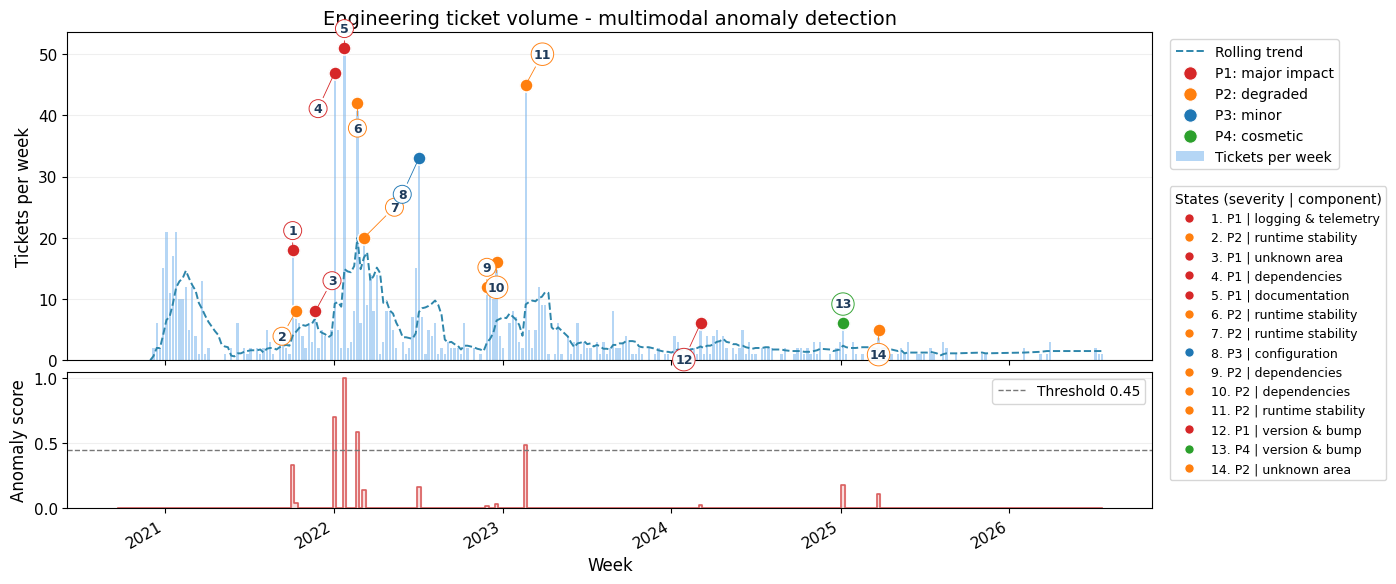

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


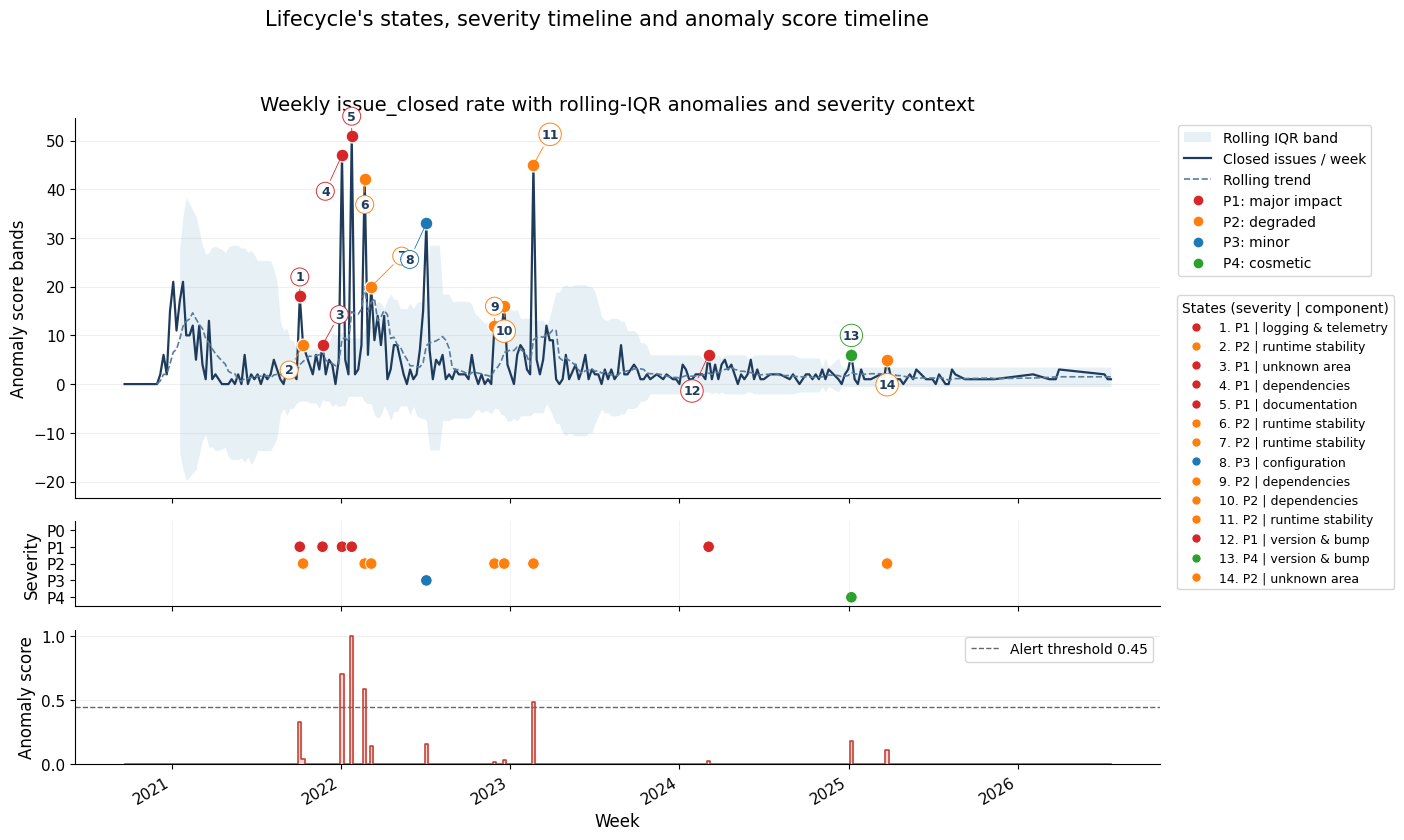

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/FinRL')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 14 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinRL\commit_context.csv
commit_typeclass_per_week summary: 14 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.000
  bug_fixes     0.000
  tech_debt     0.000
  docs          0.000
  other         0.929

Mean category ratios by anomaly_direction:
  [high] feature_work=0.000  bug_fixes=0.000  tech_debt=0.000  docs=0.000  other=0.929

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinRL\commit_typeclass_per_week.csv


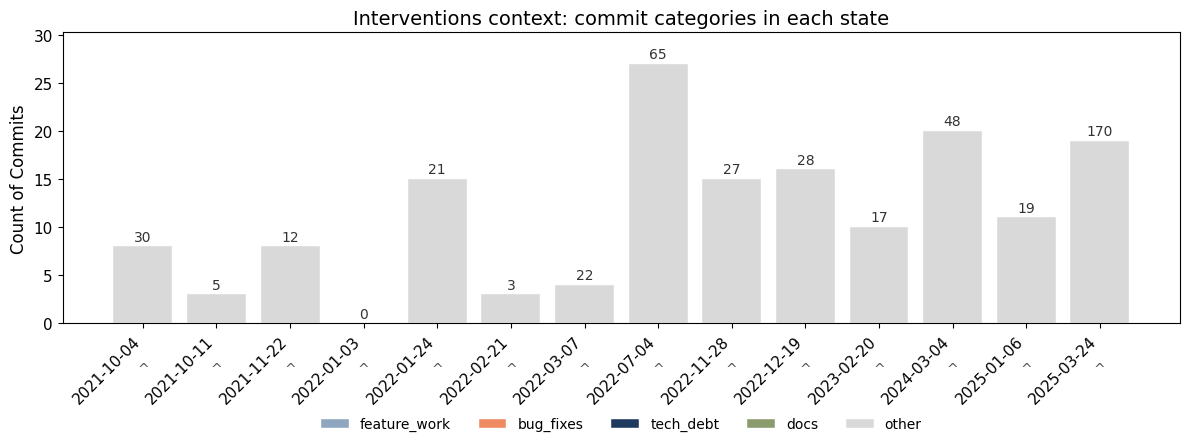

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/FinRL')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 9630 events, 1008 cases
  case:concept:name      concept:name            time:timestamp
0             10158         committed 2024-07-06 00:29:05+00:00
1             10158           created 2024-07-06 00:29:06+00:00
2             10158           labeled 2024-07-06 00:29:07+00:00
3             10158            merged 2024-07-06 15:05:25+00:00
4             10158            closed 2024-07-06 15:05:25+00:00
5             10158  head_ref_deleted 2024-07-06 15:05:28+00:00
6             10158        referenced 2024-12-31 06:39:17+00:00
7             10158        referenced 2025-01-01 08:21:41+00:00
8             10193         committed 2024-02-11 09:42:04+00:00
9             10193         committed 2024-02-11 09:46:16+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 3107 rows, 309 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 257 -> 209 cases | 2308 -> 1285 events
Whole: 759 -> 650 cases | 6428 -> 3826 events
Random control (rebuilt): 209 cases | 1250 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 106/106 [00:00<00:00, 1142.78it/s]

Expected records: 51 | Observed: 51

7) Consolidated results table in clean logs
               log_name             discovery_method  distinct_traces  \
0   random_case_control                alpha_classic              106   
1            vitalizing                alpha_classic              123   
2                 whole                alpha_classic              246   
3   random_case_control           heuristics_dep_0.5              106   
4            vitalizing           heuristics_dep_0.5              123   
5                 whole           heuristics_dep_0.5              246   
6   random_case_control           heuristics_dep_0.6              106   
7            vitalizing           heuristics_dep_0.6              123   
8                 whole           heuristics_dep_0.6              246   
9   random_case_control           heuristics_dep_0.7              106   
10           vitalizing           heuristics_dep_0.7              123   
11                whole           heuristic

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,106,0.644051,0.537760,0.155099,0.240759,114.0,27.0,0.411765,ok,None
1,vitalizing,alpha_classic,123,0.718488,0.607744,0.247822,0.352077,67.0,13.0,0.560000,ok,None
2,whole,alpha_classic,246,0.748132,0.548785,0.174115,0.264357,108.0,24.0,0.440860,ok,None
3,random_case_control,heuristics_dep_0.5,106,0.524031,0.874757,0.529682,0.659826,372.0,22.0,0.493333,ok,None
4,vitalizing,heuristics_dep_0.5,123,0.525229,0.798468,0.702980,0.747687,276.0,18.0,0.484444,ok,None


## 10. Utility figures


Plotting from 51 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.5', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'inductive_IM', 'inductive_IMf_noise_0.2', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'split_miner_eps_0.1_eta_0.4', 'split_miner_eps_0.1_eta_0.5', 'split_miner_eps_0.1_eta_0.6', 'split_miner_eps_0.2_eta_0.4', 'split_miner_eps_0.2_eta_0.5', 'split_miner_eps_0.2_eta_0.6', 'split_miner_eps_0.3_eta_0.4', 'split_miner_eps_0.3_eta_0.5', 'split_miner_eps_0.3_eta_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinRL\clean_log_f_score_grouped_bars.{png,pdf}


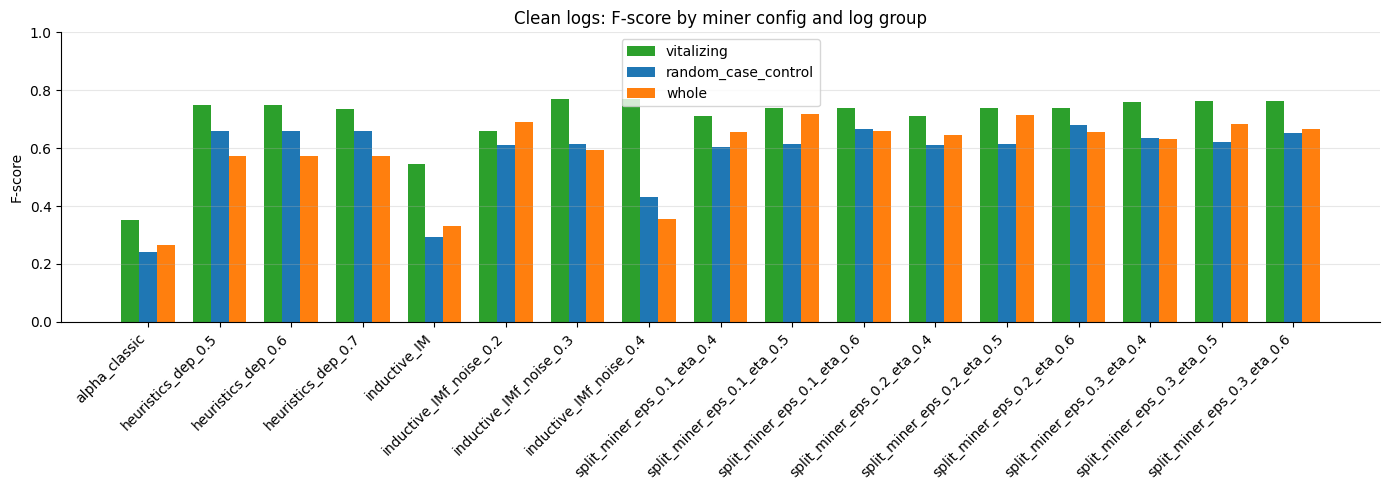

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinRL\clean_log_fitness_precision.{png,pdf}


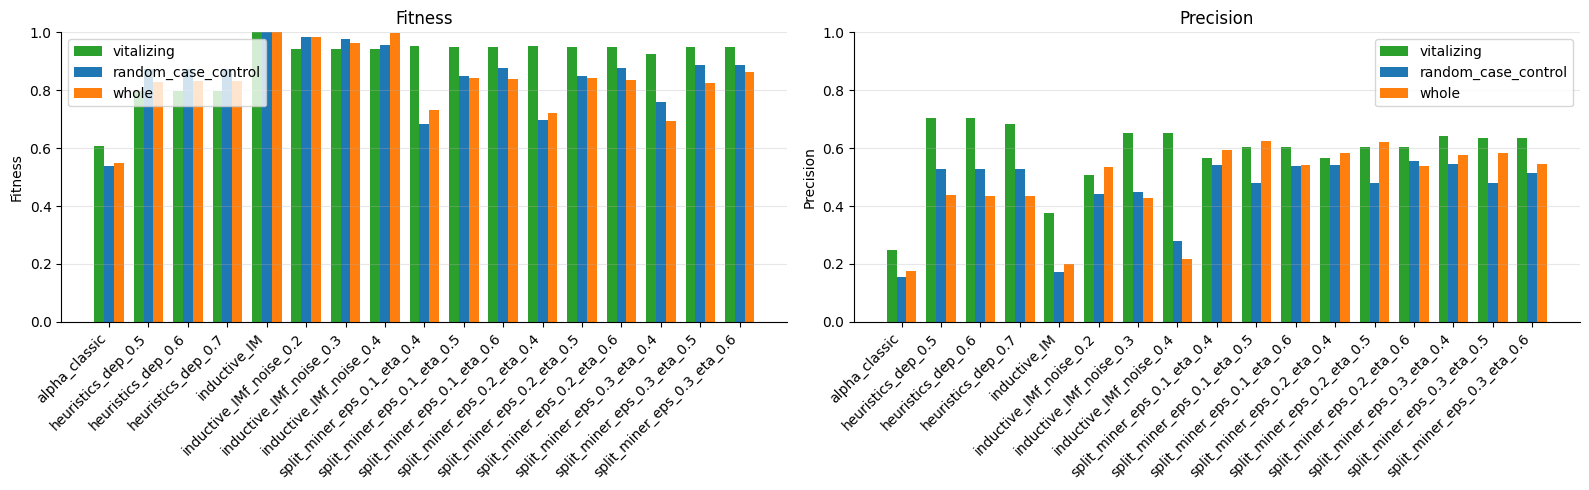

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinRL\clean_log_complexity.{png,pdf}


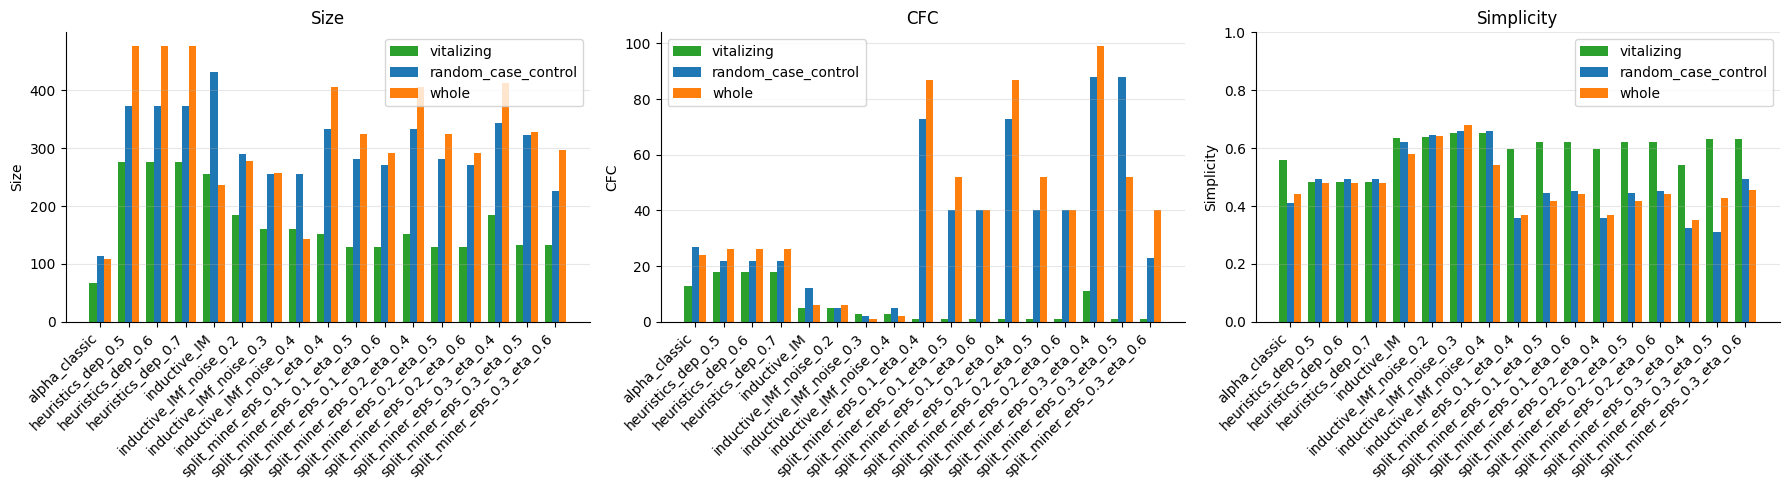

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinRL\clean_log_threshold_sensitivity.{png,pdf}


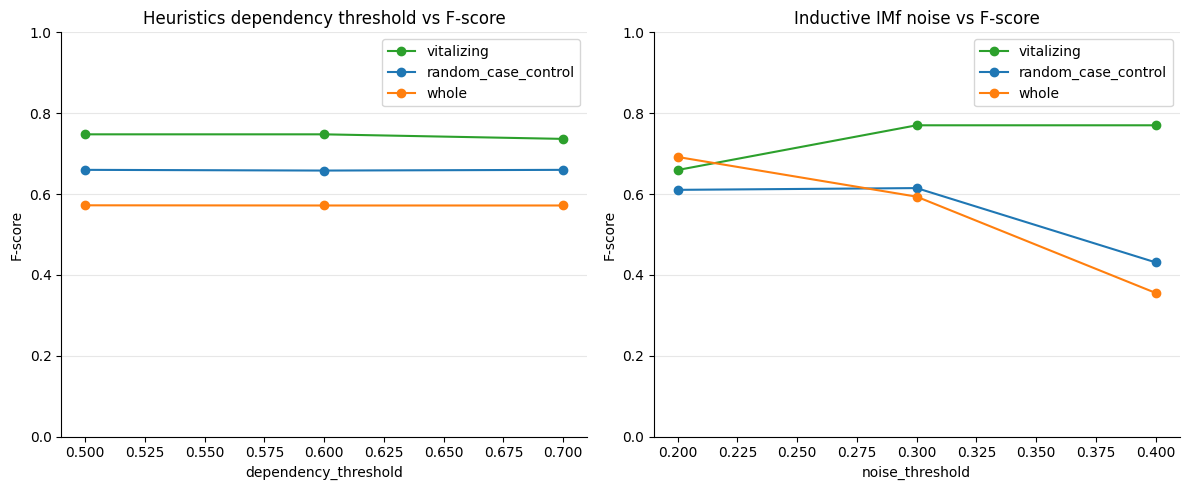

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinRL\clean_log_f_score_slopegraph.{png,pdf}


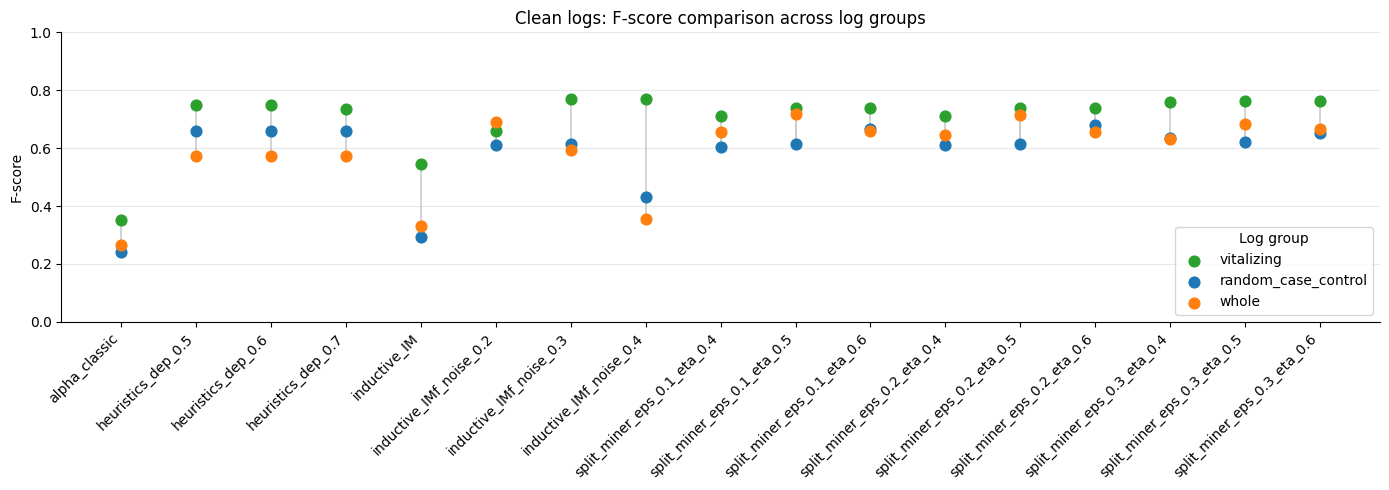

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.5  heuristics_dep_0.6  \
 log_name                                                                     
 random_case_control       0.240759            0.659826            0.658062   
 vitalizing                0.352077            0.747687            0.747687   
 whole                     0.264357            0.572108            0.571650   
 
 discovery_method     heuristics_dep_0.7  inductive_IM  \
 log_name                                                
 random_case_control            0.659826      0.294531   
 vitalizing                     0.736409      0.545173   
 whole                          0.571677      0.331435   
 
 discovery_method     inductive_IMf_noise_0.2  inductive_IMf_noise_0.3  \
 log_name                                                                
 random_case_control                 0.610352                 0.614700   
 vitalizing                          0.659418                 0.770

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 107/107 [00:00<00:00, 950.44it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
               discovery_method  fitness_mean  fitness_std  fitness_cv  \
0                 alpha_classic      0.594056     0.038704    0.065153   
1            heuristics_dep_0.5      0.837579     0.019440    0.023209   
2            heuristics_dep_0.6      0.837420     0.018790    0.022438   
3            heuristics_dep_0.7      0.837458     0.018632    0.022248   
4                  inductive_IM      1.000000     0.000000    0.000000   
5       inductive_IMf_noise_0.2      0.981158     0.004783    0.004875   
6       inductive_IMf_noise_0.3      0.975783     0.011537    0.011823   
7       inductive_IMf_noise_0.4      0.950488     0.018273    0.019225   
8   split_miner_eps_0.1_eta_0.4      0.904117     0.058892    0.065137   
9   split_miner_eps_0.1_eta_0.5      0.915870     0.062347    0.068074   
10  split_miner_eps_0.1_eta_0.6      0.923239     0.036652    0.039700  

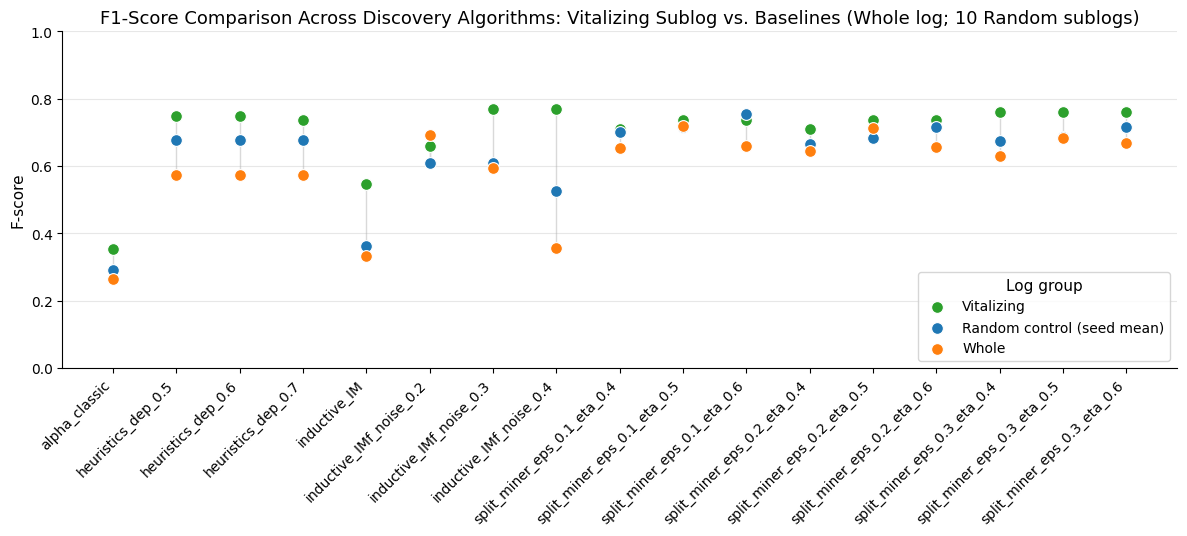

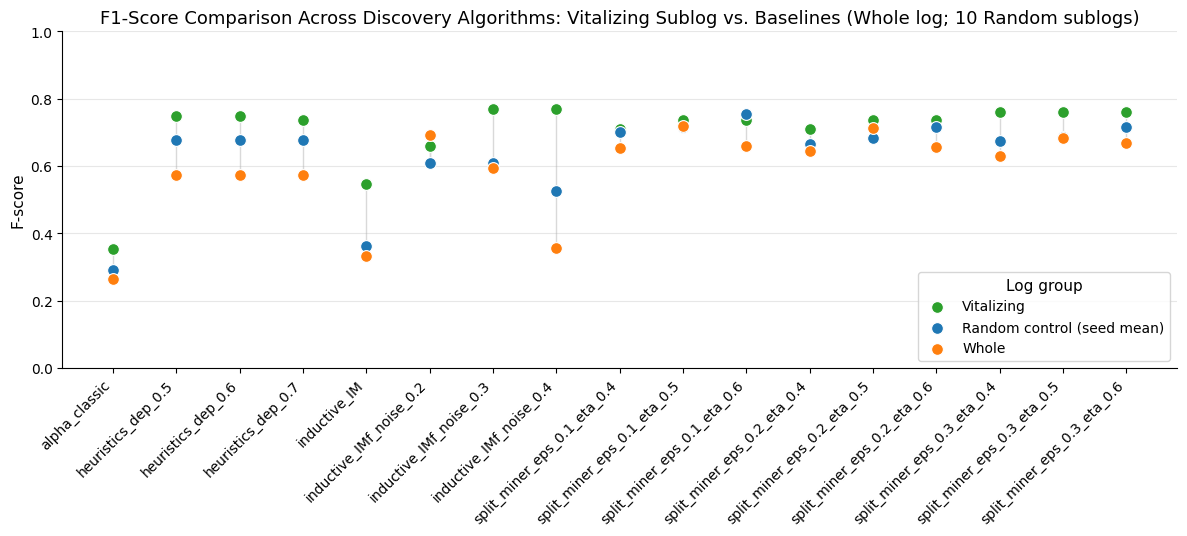

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)
